In [1]:
import pandas as pd
import numpy as np
import os
import random
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import metrics

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                                 ConfusionMatrixDisplay, precision_recall_fscore_support)


2026-04-12 17:46:08.153225: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-12 17:46:08.153487: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-12 17:46:08.198622: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-12 17:46:09.358077: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

#### BCO Coral Bleaching - Feature Engineering & Baseline Modeling
**Input:** `bco_supervised_clean.csv` produced by `BCO_Prep_EDA.ipynb` after:
- Dropping 15 unitless ID/comment columns
- Dropping redundant Kelvin, date-part, and SSTA/TSA min/mean columns
- Dropping NaN rows from target, casting all columns to numeric
- Removing 47 fully duplicate rows
- Year extracted from date as temporal feature

**Rows:** 34,468 labeled observations

In [2]:
# Load supervised_df
df_full = pd.read_csv('bco_supervised_clean.csv')

# Shape
print(f"Shape of df_full: {df_full.shape}")
df_full.head()

Shape of df_full: (34468, 38)


,latitude_degrees,longitude_degrees,distance_to_shore,exposure,turbidity,cyclone_frequency,depth_m,substrate_name,percent_cover,percent_bleaching,...,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean,date,year
0,23.163,-82.5260,8519.23,Exposed,0.0287,49.90,10.00,NaN,NaN,50.2,...,0.00,1.09,5.0,0.0,0.00,0.74,7.25,0.18,2005-09-15,2005
1,-17.575,-149.7833,1431.62,Exposed,0.0262,51.20,14.00,NaN,NaN,50.7,...,0.25,0.93,4.0,0.0,0.26,0.67,4.65,0.19,1991-03-15,1991
2,18.369,-64.5640,182.33,Exposed,0.0429,61.52,7.00,NaN,NaN,50.9,...,7.00,1.31,7.0,0.0,0.00,1.04,11.66,0.26,2006-01-15,2006
3,17.760,-64.5680,313.13,Exposed,0.0424,65.39,9.02,NaN,NaN,50.9,...,3.00,0.94,4.0,0.0,0.00,0.75,5.64,0.20,2006-04-15,2006
4,17.769,-64.5830,792.00,Exposed,0.0424,65.39,12.50,NaN,NaN,50.9,...,3.00,1.33,5.0,0.0,0.00,0.92,6.89,0.25,2006-04-15,2006


In [3]:
print(f"Unique values in df_full columns:\n{df_full.nunique().sort_values().head(10)}")
print(f"\nNAN values in df_full columns:\n{df_full.isna().sum().sort_values(ascending=False).head()}")

Unique values in df_full columns:
exposure                     3
substrate_name               3
windspeed                   18
year                        36
tsa_frequencymean           72
ssta_standard_deviation    120
ssta_frequencymean         147
tsa_frequency              197
tsa_frequencymax           216
tsa_dhwmean                232
dtype: int64

NAN values in df_full columns:
substrate_name    12015
percent_cover     11810
depth_m            1679
ssta                122
ssta_dhw            122
dtype: int64


percent_cover and substrate_name have lot of nan's. 
<br>Percent cover is a method of determining relative abundance of a plant or sessile animal based on the amount of space they occupy within a plot of substrate. In this method, rather than counting the number of individuals, each species is assigned a percent cover based on a visual estimate of how much of the sample plot they occupy. So percent_cover depends on substrate, its not missing at random and cannot be imputed. It could be dropped as a feature as its not meaningful for prediction.
<br> substrate_name also cannot be imputed as we don’t know whether missing substrate_name means “no substrate observed”, “not recorded”, etc. But its useful as a feature so we will fill the nan's with the value 'unknown' 

In [4]:
# Its ok to fill nan with 'unknown' for this feature column as it is a categorical label, 
# so there is no risk of data leakage.
df_full['substrate_name'] = df_full['substrate_name'].fillna('unknown')

#### Workflow Planning:

1. Column grouping (already done in BCO_Prep_EDA notebook)
2. Target variable distribution analysis - distribution of percent_bleaching, class imbalance check (already done in BCO_Prep_EDA notebook)
3. Define X, y
4. Data splits - Stratified/ Temporal?
5. Feature distribution within feature groups - histogram/ bar charts.
6. undersampling approach to handle class imbalance  - training set only
7. Feature analysis - Correlation + redundancy analysis - Training set only.
8. Feature selection - drop redundant features, PCA
9. Define baseline model
10. Model fit - train model - training set only
11. Model evaluate - val set only - Accuracy, Precision/ Recall, Confusion matrix 
12. Improved models - RF/Tree/boosting
13. Evaluation - test set only - Accuracy, Precision/ Recall, Macro F1, Confusion matrix 

#### Bleaching Class Definition 
Target Variable: Bleaching Class Redefinition
The original binning strategy used three classes: Low (0–10%), Medium (11–30%), and High (31–100%). While intuitive, this resulted in a severely imbalanced class distribution. Class 1 had the lowest samples, making it the hardest class to learn. 
- class 0 : Low : 27666, 80.3%
- class 1 : Medium : 2525, 7.3%
- class 2 : High : 4277, 12.4%

Upon further research, we updated the bleaching classification bins to shift the low threshold from 10% to 1%. The rationale behind this approach is to separate reefs with negligible bleaching from stressed reefs. The medium category is a better representation of reefs under moderate thermal stress and shows the ecologically critical early-warning zone. High category is the same, showing severely bleached reefs requiring intervention. As shown below class 1 has increased to ~10k smaples from ~2k samples. While the class imbalance still persists, it has improved as compared to the previous approach.
- class 0 : Low : 19926, 57.8% 
- class 1 : Medium : 10265, 29.8%
- class 2 : High : 4277, 12.4%

In [5]:
# Redefine target variable
# Bleaching class
# <= 10 Low
# 11 - 30 Medium
# 31 High
bins = [-0.01, 1, 30, 100]

labels = [0, 1, 2]  # 0=low, 1=medium, 2=high

df_full['bleaching_class'] = pd.cut(
    df_full['percent_bleaching'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(int)

# check the target's class distribution
print(df_full['bleaching_class'].value_counts().sort_index())
# print(df_full.groupby('bleaching_class').size())
print(df_full['bleaching_class'].value_counts(normalize=True).round(3).sort_index())


bleaching_class
0    19926
1    10265
2     4277
Name: count, dtype: int64
bleaching_class
0    0.578
1    0.298
2    0.124
Name: proportion, dtype: float64


#### Define X,y variable followed by data splits

In [6]:
# Drop columns not used in modelling
df_full = df_full.drop(columns=['percent_bleaching', 'date', 'percent_cover'], errors='ignore')

## Identify feature columns
feature_cols = [col for col in df_full.columns if col != 'bleaching_class']

# Define X and y variables
X = df_full[feature_cols]
y = df_full['bleaching_class']

The dataset is split into training (60%), validation (20%), and test (20%) sets using stratify=y to preserve the class distribution across all splits. Stratification is important here given the class imbalance. Without it, minority classes could be underrepresented in the validation or test sets, producing unreliable evaluation metrics.

- X_train / y_train used exclusively for model fitting and feature analysis
- X_val / y_val used for hyperparameter decisions and model comparison during development
- X_test / y_test held out entirely; used only for final evaluation

All correlation and VIF analysis is performed on the training set only to prevent data leakage.

In [7]:
# Data Split 60:20:20

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

 # Shape of each dataframe
print('Size of X_train', X_train.shape)
print('Size of Y_train', y_train.shape)
print('Size of X_val', X_val.shape)
print('Size of Y_val', y_val.shape)
print('Size of X_test', X_test.shape)
print('Size of Y_test', y_test.shape)

Size of X_train (20680, 35)
Size of Y_train (20680,)
Size of X_val (6894, 35)
Size of Y_val (6894,)
Size of X_test (6894, 35)
Size of Y_test (6894,)


In [8]:
# df for y_train and X_train
df_train = pd.concat([pd.DataFrame(y_train), pd.DataFrame(X_train)], axis=1)

In [9]:
df_train.columns

Index(['bleaching_class', 'latitude_degrees', 'longitude_degrees',
       'distance_to_shore', 'exposure', 'turbidity', 'cyclone_frequency',
       'depth_m', 'substrate_name', 'climsst', 'temperature_mean',
       'temperature_maximum', 'windspeed', 'ssta', 'ssta_standard_deviation',
       'ssta_maximum', 'ssta_frequency', 'ssta_frequency_standard_deviation',
       'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw',
       'ssta_dhw_standard_deviation', 'ssta_dhwmax', 'ssta_dhwmean', 'tsa',
       'tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency',
       'tsa_frequency_standard_deviation', 'tsa_frequencymax',
       'tsa_frequencymean', 'tsa_dhw', 'tsa_dhw_standard_deviation',
       'tsa_dhwmax', 'tsa_dhwmean', 'year'],
      dtype='object')

Given the large number of features in the dataset, we grouped the features for the ease of plotting and analysis.

In [10]:
# group feature columns for analysis
feature_groups = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'], #4
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw', 'tsa_dhw'], #5
'ssta_family': [ 'ssta_standard_deviation', 'ssta_maximum', 'ssta_frequency', #9
       'ssta_frequency_standard_deviation', 'ssta_frequencymax',
       'ssta_frequencymean', 'ssta_dhw_standard_deviation', 'ssta_dhwmax', 
       'ssta_dhwmean'],
'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency', #9
       'tsa_frequency_standard_deviation', 'tsa_frequencymax', 'tsa_frequencymean', 
       'tsa_dhw_standard_deviation', 'tsa_dhwmax', 'tsa_dhwmean'],
'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed', 'turbidity', #5
                  'cyclone_frequency'],
# 'categorical': ['exposure', 'substrate_name'], #2
'temporal': ['year'], #1
}

In [11]:
# Numeric columns for correlation matrix
numeric_cols = df_train[feature_cols].select_dtypes(include=['int64', 'float64']).columns

#### Correlation Matrices:
The previous implementation uses the default .corrwith() method, which computes Pearson correlation. We decided to switch to Spearman rank correlation due to the following reasons:
1. bleaching_class is an ordinal encoded integer (0, 1, 2), not a continuous variable. Pearson assumes a linear relationship between continuous variables and applying it to an ordinal target introduces assumptions that don't hold.
2. Several features (e.g. ssta_dhw, depth_m) are right-skewed, violating Pearson's normality assumption. (As per histograms plotted in the BCO_Final_Preprocessing_EDA.ipynb notebook.)
3. Spearman correlation measures monotonic relationships without assuming linearity or normality, making it better suited for ordinal targets and skewed distributions.

In [12]:
# Correlations with Target
for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 0:
        print(f"\n=== {group_name.upper()} vs TARGET ===")
        corr_vals = df_train[numeric_group_cols].corrwith(df_train['bleaching_class'], method='spearman')
        display(corr_vals.sort_values(ascending=False))


=== SPATIAL vs TARGET ===


distance_to_shore    0.274619
latitude_degrees     0.154271
depth_m              0.142185
longitude_degrees   -0.241851
dtype: float64


=== THERMAL_BASELINE vs TARGET ===


tsa_dhw     0.280813
ssta_dhw    0.189257
tsa         0.161234
ssta        0.100274
climsst    -0.081174
dtype: float64


=== SSTA_FAMILY vs TARGET ===


...

tsa_frequency                       0.141591
tsa_standard_deviation              0.096931
tsa_maximum                        -0.053008
tsa_dhwmax                         -0.140702
tsa_dhw_standard_deviation         -0.190056
tsa_dhwmean                        -0.207866
tsa_frequencymax                   -0.217011
tsa_frequencymean                  -0.230280
tsa_frequency_standard_deviation   -0.236161
dtype: float64


=== ENVIRONMENTAL vs TARGET ===


windspeed              0.057203
cyclone_frequency      0.056930
turbidity             -0.039615
temperature_maximum   -0.047230
temperature_mean      -0.165117
dtype: float64


=== TEMPORAL vs TARGET ===


year   -0.237103
dtype: float64

#### I. Correlation results with target:

1. Spatial - weak correlations overall - spatial gradients are not strong predictors of bleaching, they are safe to keep, but they won’t dominate prediction. depth_m (0.14) - `keep`

2. Thermal Baseline - Bleaching is overwhelmingly driven by thermal stress. DHW metrics (ssta_dhw, tsa_dhw) are good predictors so far. DHW (Degree Heating Weeks) variables show the most meaningful relationship with the target as accumulated heat stress is the primary driver of bleaching.
    - **tsa** (0.16) and **ssta** (0.10)
    - **tsa_dhw** (0.28) and **ssta_dhw** (0.255) `keep`, highly correlated with each other - need only 1 of these, but we can keep both for tree‑based models.  

3. SSTA family - This group is highly redundant, and only two features show mild positive correlation
    
    - **ssta_standard_deviation** (0.257) `keep`
    - **ssta_frequency** (0.09) - `keep`
    - **ssta_maximum** (0.003) - `Drop`
    - Most **dhwmean**, **dhw_standard_deviation**, **dhwmax**  (all near zero or negative) `Drop`        

4. TSA family - 
    - **tsa_frequency** (0.149) - `keep` mildly predictive
    - **tsa_maximum** (0.003) - `Drop`
    - everything else is redundant

5. Environment - no meaningful correlation
        - **windspeed** (0.05), **cyclone_frequency** (0.024) - `Drop`
        - **turbidity** (-0.04), **temperature_mean** (-0.077) - `Drop`
        - **temperature_mean** (-0.17) - `keep'

6. Temporal - Bleaching severity decreases slightly over time. sampling bias? recovery?
        - **year** (-0.23) — Moderate negative correlation suggests a temporal trend. 


Given the large number of features in the dataset, we applied a correlation threshold of |r| > 0.4 to surface only the most meaningful relationships within each feature group. This will help reduce noise from weak or incidental correlations and highlights pairs of variables that may contribute redundant information or multicollinearity. <br>
We use the default - Pearson correlation here since the goal is to identify linear dependencies among features within each group.

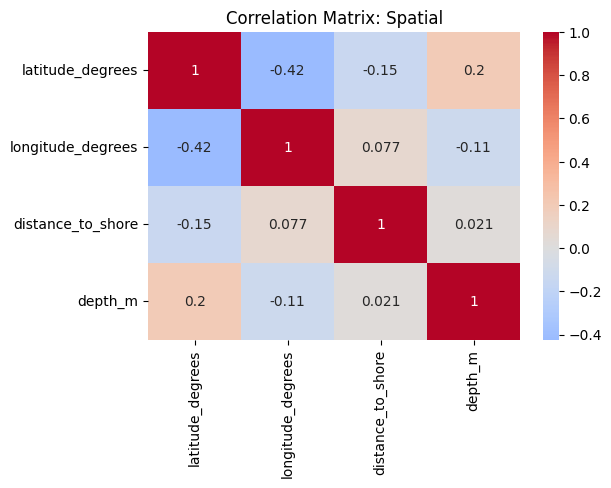

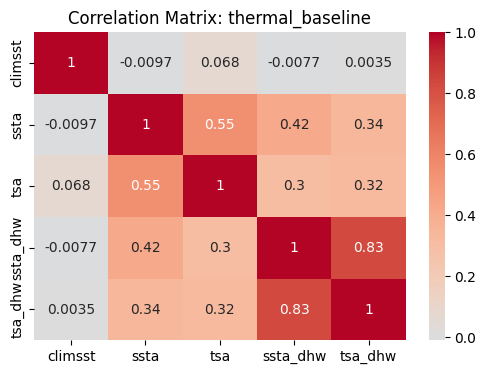

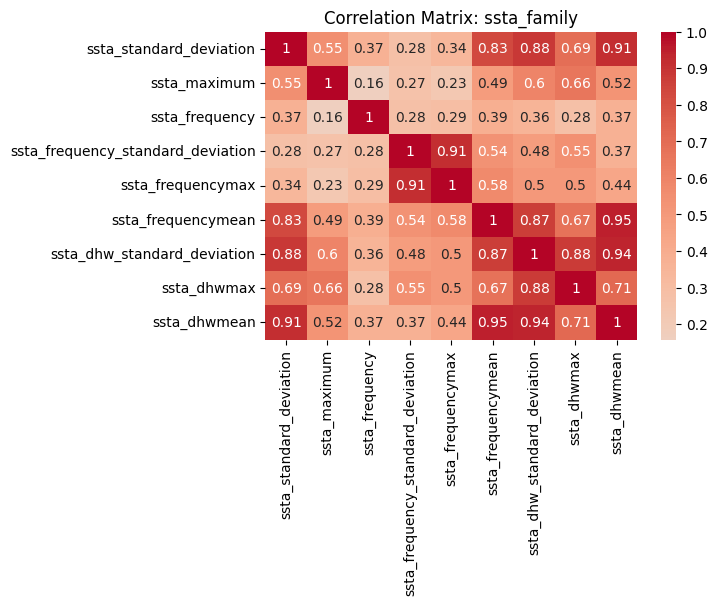

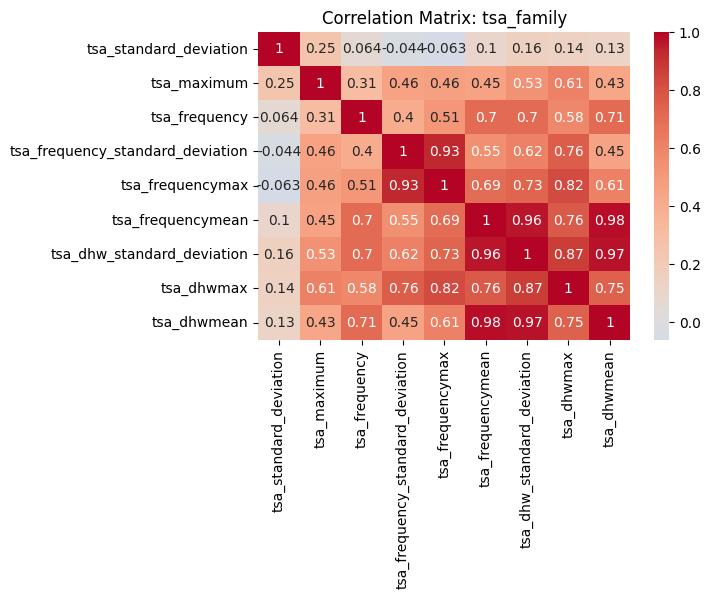

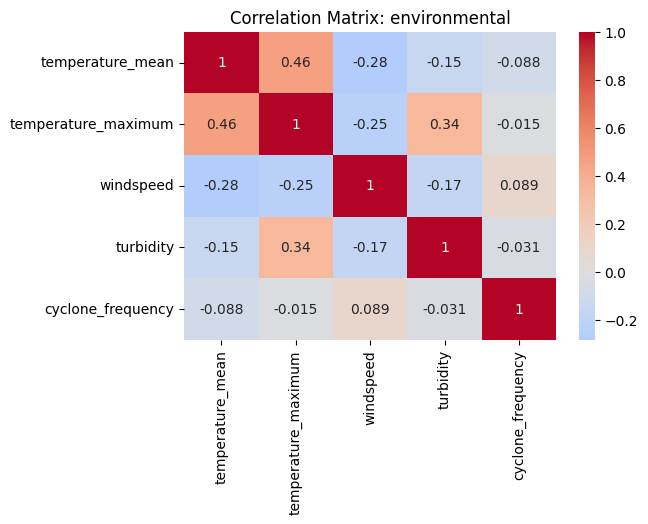

In [13]:
# Correlation between feature groups to check for multicolinearity

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 1:
        plt.figure(figsize=(6, 4))
        sns.heatmap(df_train[numeric_group_cols].corr(), annot=True, cmap='coolwarm', center=0)
        plt.title(f"Correlation Matrix: {group_name}")
        plt.show()


In [14]:
threshold = 0.4

for group_name, cols in feature_groups.items():
    numeric_group_cols = [c for c in cols if c in numeric_cols]
    
    if len(numeric_group_cols) > 1:
        corr = df_train[numeric_group_cols].corr()
        filtered = corr[(corr.abs() > threshold) & (corr.abs() != 1)]
        
        print(f"\n=== {group_name.upper()} (|r| > {threshold}) ===")
        display(filtered)



=== SPATIAL (|r| > 0.4) ===


,latitude_degrees,longitude_degrees,distance_to_shore,depth_m
latitude_degrees,NaN,-0.42498,NaN,NaN
longitude_degrees,-0.42498,NaN,NaN,NaN
distance_to_shore,NaN,NaN,NaN,NaN
depth_m,NaN,NaN,NaN,NaN



=== THERMAL_BASELINE (|r| > 0.4) ===


,climsst,ssta,tsa,ssta_dhw,tsa_dhw
climsst,NaN,NaN,NaN,NaN,NaN
ssta,NaN,NaN,0.549319,0.419266,NaN
tsa,NaN,0.549319,NaN,NaN,NaN
ssta_dhw,NaN,0.419266,NaN,NaN,0.83431
tsa_dhw,NaN,NaN,NaN,0.834310,NaN



=== SSTA_FAMILY (|r| > 0.4) ===


,ssta_standard_deviation,ssta_maximum,ssta_frequency,ssta_frequency_standard_deviation,ssta_frequencymax,ssta_frequencymean,ssta_dhw_standard_deviation,ssta_dhwmax,ssta_dhwmean
ssta_standard_deviation,NaN,0.548409,NaN,NaN,NaN,0.834415,0.882311,0.690767,0.913682
ssta_maximum,0.548409,NaN,NaN,NaN,NaN,0.485061,0.597347,0.662705,0.523179
ssta_frequency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ssta_frequency_standard_deviation,NaN,NaN,NaN,NaN,0.911448,0.535637,0.479997,0.545925,NaN
ssta_frequencymax,NaN,NaN,NaN,0.911448,NaN,0.575182,0.501170,0.503272,0.436081
ssta_frequencymean,0.834415,0.485061,NaN,0.535637,0.575182,NaN,0.870485,0.671795,0.946775
ssta_dhw_standard_deviation,0.882311,0.597347,NaN,0.479997,0.501170,0.870485,NaN,0.877489,0.943430
ssta_dhwmax,0.690767,0.662705,NaN,0.545925,0.503272,0.671795,0.877489,NaN,0.714905
ssta_dhwmean,0.913682,0.523179,NaN,NaN,0.436081,0.946775,0.943430,0.714905,NaN



=== TSA_FAMILY (|r| > 0.4) ===


,tsa_standard_deviation,tsa_maximum,tsa_frequency,tsa_frequency_standard_deviation,tsa_frequencymax,tsa_frequencymean,tsa_dhw_standard_deviation,tsa_dhwmax,tsa_dhwmean
tsa_standard_deviation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsa_maximum,NaN,NaN,NaN,0.457914,0.461302,0.452921,0.534843,0.610100,0.434372
tsa_frequency,NaN,NaN,NaN,NaN,0.507241,0.704434,0.703407,0.577559,0.706691
tsa_frequency_standard_deviation,NaN,0.457914,NaN,NaN,0.930798,0.551566,0.615703,0.758284,0.450484
tsa_frequencymax,NaN,0.461302,0.507241,0.930798,NaN,0.693239,0.733624,0.818698,0.614836
tsa_frequencymean,NaN,0.452921,0.704434,0.551566,0.693239,NaN,0.961732,0.763572,0.975601
tsa_dhw_standard_deviation,NaN,0.534843,0.703407,0.615703,0.733624,0.961732,NaN,0.868121,0.969534
tsa_dhwmax,NaN,0.610100,0.577559,0.758284,0.818698,0.763572,0.868121,NaN,0.745408
tsa_dhwmean,NaN,0.434372,0.706691,0.450484,0.614836,0.975601,0.969534,0.745408,NaN



=== ENVIRONMENTAL (|r| > 0.4) ===


,temperature_mean,temperature_maximum,windspeed,turbidity,cyclone_frequency
temperature_mean,NaN,0.462734,NaN,NaN,NaN
temperature_maximum,0.462734,NaN,NaN,NaN,NaN
windspeed,NaN,NaN,NaN,NaN,NaN
turbidity,NaN,NaN,NaN,NaN,NaN
cyclone_frequency,NaN,NaN,NaN,NaN,NaN


#### I. Feature correlation results:

1. Spatial - light correlations overall.  - `keep all`

2. Thermal Baseline - Bleaching is overwhelmingly driven by thermal stress. DHW metrics (ssta_dhw, tsa_dhw) are good predictors so far. DHW (Degree Heating Weeks) variables show the most meaningful relationship with the target as accumulated heat stress is the primary driver of bleaching. SSTA and TSA track similar thermal anomalies. DHW metrics are derived from anomalies, so they cluster.
    - **tsa** and **ssta** (0.55) - `keep`
    - **ssta** and **ssta_dhw** (0.41) - `keep`
    - **tsa_dhw** and **ssta_dhw** (0.82) `keep`, highly correlated with each other - need only 1 of these, but we can keep both for tree‑based models.

3. SSTA family - This group has extremely high correlations. classic multicollinearity - features are all derived from the same underlying SST anomaly time series. Run PCA to select features? PCA? dimensionality reduction? or similar to target correlations -
    
    - **ssta_standard_deviation**  `keep`
    - **ssta_frequency**  - `keep`
    - **ssta_maximum** - `Drop`
    - Most **dhwmean**, **dhw_standard_deviation**, **dhwmax**  `Drop`        

4. TSA family - mirrors the SSTA family because TSA is a parallel anomaly metric. Group is internally redundant. PCA? dimensionality reduction? or similar to target correlations -
    - **tsa_frequency** - `keep`
    - **tsa_maximum**  - `Drop`
    - everything else is redundant

5. Environment - Only one moderate correlation
        - **temperature_max** and **temperature_mean** (0.45) - `Drop`  

In [15]:
# Feature Selection - selecting 13 features for baseline model as per analysis above.

keep_features = {
'Spatial': ['latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m'],
'thermal_baseline': ['climsst', 'ssta', 'tsa', 'ssta_dhw'],
'ssta_family': ['ssta_standard_deviation','ssta_frequency'],
'tsa_family': ['tsa_frequency'],
'environmental': ['turbidity', 'cyclone_frequency'],
'temporal': ['year'],
'categorical': ['exposure', 'substrate_name']}

# drop_features = {
# 'Spatial': [],
# 'thermal_baseline': ['tsa_dhw'],
# 'ssta_family': ['ssta_maximum', 'ssta_frequency_standard_deviation', 
#                 'ssta_frequencymax', 'ssta_frequencymean', 'ssta_dhw_standard_deviation', 
#                 'ssta_dhwmax', 'ssta_dhwmean'],
# 'tsa_family': ['tsa_standard_deviation', 'tsa_maximum', 'tsa_frequency_standard_deviation', 
#                'tsa_frequencymax', 'tsa_frequencymean', 'tsa_dhw_standard_deviation', 
#                'tsa_dhwmax', 'tsa_dhwmean'],
# 'environmental': ['temperature_mean', 'temperature_maximum', 'windspeed']}

In [16]:
# Flatten the keep_features dictionary into a single list
keep_features_flat = [f for group in keep_features.values() for f in group]

# copy to a new dataframe
df_train = df_train[keep_features_flat]
print(df_train.shape)
df_train.head()

(20680, 16)


,latitude_degrees,longitude_degrees,distance_to_shore,depth_m,climsst,ssta,tsa,ssta_dhw,ssta_standard_deviation,ssta_frequency,tsa_frequency,turbidity,cyclone_frequency,year,exposure,substrate_name
15703,4.5981,118.8619,32.43,5.0,302.09,0.57,0.01,2.06,0.80,10.0,3.0,0.0727,54.54,2018,Sheltered,Hard Coral
8012,22.5506,114.3092,71.82,3.0,300.24,-0.22,-0.49,0.00,1.64,3.0,0.0,0.4006,55.21,2005,Sheltered,Nutrient Indicator Algae
34054,24.5001,-81.6296,8411.00,5.1,299.79,3.91,3.91,51.11,2.58,25.0,25.0,0.1203,58.42,2015,Exposed,unknown
611,24.8360,-80.7280,1490.84,3.2,300.55,0.58,-0.52,4.91,1.00,4.0,2.0,0.1836,60.12,2005,Sometimes,unknown
14121,4.5211,118.8048,4225.93,7.0,301.80,-0.34,-0.53,0.00,0.81,8.0,0.0,0.1644,54.53,2017,Sheltered,Hard Coral


In [17]:
# Compute VIF on the reduced feature set
# VIF runs on numeric data and does not consider Nan's
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF
numeric_cols_for_vif = df_train.select_dtypes(include=['int64', 'float64']).columns
df_vif = df_train[numeric_cols_for_vif].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(df_vif.values, i)
    for i in range(df_vif.shape[1])
]

vif_data

,feature,VIF
0,latitude_degrees,2.194734
1,longitude_degrees,1.472224
2,distance_to_shore,1.123017
3,depth_m,4.132111
4,climsst,414.166715
5,ssta,1.735320
6,tsa,1.992316
7,ssta_dhw,2.733788
8,ssta_standard_deviation,33.503360
9,ssta_frequency,4.602572


Most VIF values are between 1 and 5. 3 features stand out: climsst 411, cyclone_frequency 60, ssta_std_deviation 33 and year 464.
climsst is the long‑term climatological SST, and it is strongly tied to lat/long, ssta(anomaly = sst - climsst), tsa, ssta_dhw (derived from anomalies). So it’s mathematically redundant and we can `drop` it. 

cyclone_frequency is surprising and hard to explain. It's probably correlating with a spatial or geographic variable. Cyclone frequency is strongly tied to year and location in many datasets.
If cyclone events cluster in certain years or regions, VIF will explode. - `Drop`

ssta_std_deviation is correlated with SST variability metrics - `Drop`

In [18]:
# Drop climsst and rerun VIF
numeric_cols_for_vif = df_train.select_dtypes(include=['int64', 'float64']).columns
numeric_cols_for_vif = numeric_cols_for_vif.drop(['climsst', 'cyclone_frequency', 'ssta_standard_deviation'])
df_vif = df_train[numeric_cols_for_vif].dropna().copy()

vif_data = pd.DataFrame()
vif_data["feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

vif_data

,feature,VIF
0,latitude_degrees,1.756701
1,longitude_degrees,1.420644
2,distance_to_shore,1.104627
3,depth_m,4.115813
4,ssta,1.724095
5,tsa,1.967552
6,ssta_dhw,2.602919
7,ssta_frequency,4.534949
8,tsa_frequency,2.518064
9,turbidity,2.900042


All spatial + thermal + frequency features look great! everything is below 10. Year has the highest VIF, because thermal anomalies trend over time and bleaching events cluster in certain years - worth keeping an eye on. Keep year for baseline as random forest/ boosting can handle the temporal structure later. 

We are down to 11 numeric + 2categorical features. No need to run PCA for dimensionality reduction as VIF is clean, so there is no colinearity to fix. 

Also skipping feature scaling for baseline, it can be done at the time of running NN.

In [19]:
# Features for baseline model
numeric_features = [
    'latitude_degrees', 'longitude_degrees', 'distance_to_shore', 'depth_m', 'ssta', 
    'tsa', 'ssta_dhw', 'ssta_frequency', 'tsa_frequency', 'turbidity', 'year']

categorical_features = ['exposure', 'substrate_name']

CLASS_NAMES = ['Low Bleaching', 'Medium Bleaching', 'High Bleaching']

#### Model Build + Train
Build, preprocess, and train a Logistic Regression baseline classifier for coral bleaching severity prediction.

The function constructs a sklearn Pipeline that handles all preprocessing steps inline, ensuring no data leakage between train and validation sets. Preprocessing and model fitting use the globally defined X_train / y_train splits.

Preprocessing steps:

- Numeric features (11):
    - **SimpleImputer**(strategy='median'): Imputes missing values with the column median. Median is preferred over mean for skewed environmental measurements (e.g. depth_m, ssta_dhw) as it is robust to outliers.
    - **StandardScaler**: Zero-mean, unit-variance scaling. Required for Logistic Regression, which is sensitive to feature magnitude differences. Without scaling, features with larger ranges (e.g. ssta_dhw vs turbidity) would dominate the coefficient estimates.

- Categorical features (2: exposure, substrate_name):
    - **OneHotEncoder**(drop='first', handle_unknown='ignore'): Converts nominal categories to binary dummy variables. drop='first' removes one category per feature to avoid the multicollinearity.   handle_unknown='ignore' prevents errors if unseen categories appear in the validation or test set.

We use max_iter=1000 to ensure convergence, class_weight='balanced' to address the class imbalance as it would penalize the majority class with lower weights. Default regularisation strength (L2). C is the inverse of regularisation, 1.0 is a neutral starting point for the baseline, to be tuned in experiments.

In [39]:
def build_model(X_train, y_train, numeric_strategy='median', model_params=None):
    """
    Build and train a Logistic Regression pipeline for coral bleaching
    severity prediction.

    The pipeline handles:
        - Numeric features  : imputation (median/mean) + StandardScaler
        - Categorical features : OneHotEncoder (drop first, ignore unknown)
        - Classifier        : LogisticRegression (One-vs-Rest by default)

    Parameters :
    X_train : pd.DataFrame   — Training features
    y_train : pd.Series      — Training labels
    numeric_strategy : str   — Imputation strategy ('median' or 'mean')
    model_params : dict      — kwargs passed to LogisticRegression

    Returns :
    model : fitted sklearn Pipeline
    """
    if model_params is None:
        model_params = {
            'max_iter': 1000,
            'class_weight': 'balanced',
            'C': 1.0,
            'random_state': 42
        }

    # --- Numeric preprocessing: impute then scale ---
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=numeric_strategy)),
        ('scaler',  StandardScaler())
    ])

    # --- Categorical preprocessing: one-hot encode ---
    categorical_transformer = Pipeline(steps=[
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ])

    # --- Combine into a ColumnTransformer ---
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer,     numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

    # --- Full pipeline: preprocessor + classifier ---
    model = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('clf',        LogisticRegression(**model_params))
    ])

    model.fit(X_train, y_train)
    return model


#### Model Evaluate
We evaluate the Logistic regression baseline on the validation set and report per-class and overall performance metrics.

**Metrics reported** : 

- Per-class accuracy : diagonal of confusion matrix / row sum. Reported separately because overall accuracy is misleading given the class imbalance.

- Overall accuracy : fraction of all predictions that are correct. Included for reference, its not the primary evaluation metric.

- Classification Report : per-class Precision, Recall, F1-score, and support. Macro F1 (unweighted average across classes) is the primary metric for comparing models, as it weights all classes   equally regardless of support size.

- Confusion Matrix : Off-diagonal cells show misclassification patterns.

- TP / FP / FN / TN per class : derived from the confusion matrix for manual inspection of error types.

In [51]:
def evaluate_model(model, X_train, y_train, X_val, y_val, baseline_f1_macro=None):
    """
    Fit model, predict on validation set, and return key metrics.

    Parameters :
    model               : sklearn Pipeline — unfitted model
    X_train, y_train    : training split
    X_val,   y_val      : validation split
    baseline_f1_macro   : float or None — if provided, computes % improvement

    Returns :
    metrics : dict
    """
    # Fit and predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    # Overall accuracy
    train_acc = model.score(X_train, y_train)
    val_acc   = model.score(X_val,   y_val)
    gap_pct   = abs(train_acc - val_acc) / train_acc * 100

    # Macro-averaged metrics
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_val, y_pred, average='macro', zero_division=0
    )

    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, support = \
        precision_recall_fscore_support(y_val, y_pred, average=None, zero_division=0)

    # Improvement over baseline (only for non-baseline experiments)
    if baseline_f1_macro is not None:
        improvement_pct = (f1_macro - baseline_f1_macro) / baseline_f1_macro * 100
    else:
        improvement_pct = None

    metrics = {
        "Training accuracy":                     round(train_acc,       4),
        "Validation accuracy":                   round(val_acc,         4),
        "Gap_%":                                 round(gap_pct,         2),
        "Precision_macro":                       round(precision_macro, 4),
        "Recall_macro":                          round(recall_macro,    4),
        "F1_macro":                              round(f1_macro,        4),
        "Precision_per_class_[0,1,2]":           [round(x, 4) for x in precision_per_class],
        "Recall_per_class_[0,1,2]":              [round(x, 4) for x in recall_per_class],
        "F1_per_class_[0,1,2]":                  [round(x, 4) for x in f1_per_class],
        "Support":                               support.tolist(),
        "Improvement_over_baseline_%_[F1_macro]": None if improvement_pct is None
                                                  else round(improvement_pct, 2)
    }

    return metrics

Experiments: Logistic Regression Baseline
experiments below progressively test three axes: regularisation strength, solver choice, and class imbalance handling.

In [52]:
experiments = {
    # Baseline
    "LR_baseline": build_model(
        X_train, y_train,
        numeric_strategy='median',
        model_params={'max_iter': 1000, 'class_weight': 'balanced', 'C': 1.0, 'random_state': 42}
    ),
    # Exp 1: Stronger regularization
    "LR_exp1_stronger_reg": build_model(
        X_train, y_train,
        numeric_strategy='median',
        model_params={'max_iter': 1000, 'class_weight': 'balanced', 'C': 0.1, 'random_state': 42}
    ),
    # Exp 2: Mean imputation
    "LR_exp2_mean_impute": build_model(
        X_train, y_train,
        numeric_strategy='mean',
        model_params={'max_iter': 1000, 'class_weight': 'balanced', 'C': 1.0, 'random_state': 42}
    ),
}

# RUN — collect metrics, track baseline F1 for improvement calculation

results      = {}
baseline_f1  = None

for name, model in experiments.items():
    if name == "LR_baseline":
        # Evaluate baseline — no improvement column
        results[name] = evaluate_model(model, X_train, y_train, X_val, y_val)
        baseline_f1   = results[name]["F1_macro"]
    else:
        # Compare all other experiments against baseline F1
        results[name] = evaluate_model(
            model, X_train, y_train, X_val, y_val,
            baseline_f1_macro=baseline_f1
        )

# Compile into DataFrame (one row per experiment)
lr_results_df = pd.DataFrame(results).T

# Evaluation of key metrics for each experiment using the validation data
display(lr_results_df)

,Training accuracy,Validation accuracy,Gap_%,Precision_macro,Recall_macro,F1_macro,"Precision_per_class_[0,1,2]","Recall_per_class_[0,1,2]","F1_per_class_[0,1,2]",Support,Improvement_over_baseline_%_[F1_macro]
LR_baseline,0.6596,0.6645,0.75,0.578,0.6321,0.5836,"[0.8004, 0.4996, 0.4339]","[0.8243, 0.3161, 0.7558]","[0.8122, 0.3872, 0.5513]","[3985, 2053, 856]",None
LR_exp1_stronger_reg,0.6587,0.6638,0.77,0.5771,0.6311,0.5822,"[0.8002, 0.5, 0.431]","[0.8243, 0.3142, 0.7547]","[0.8121, 0.3859, 0.5486]","[3985, 2053, 856]",-0.24
LR_exp2_mean_impute,0.6601,0.6646,0.69,0.5783,0.6329,0.5839,"[0.8004, 0.4996, 0.4348]","[0.8243, 0.3151, 0.7593]","[0.8122, 0.3865, 0.553]","[3985, 2053, 856]",0.05


#### Interpretation
Baseline overall model accuracy 66% is inflated by the dominant Class 0 showing 82% accuracy and class 2 75% accuracy. Class 1 has the lowest accuracy of 32%. <br>

<br>**Other Metrics:**

- Class 0 : Low : Precision : 0.80, Recall : 0.82, F1 : 0.81
    Strongest class,  the model has learned the majority class well. High support (3,985) helps.

- Class 1 : Medium : Precision : 0.50, Recall : 0.32, F1 : 0.39
    This is the weakest class with low recall of 32%, meaning, the model misses most of the moderate bleaching events. It frequently misclassifies moderate bleaching as other classes which is an error for reef monitoring.

- Class 2 : High : Precision : 0.43, Recall : 0.76, F1 : 0.55
    This class has high recall but low precision. The model over-predicts severe bleaching with 844 false positives.

Overall, the model is biased toward predicting extreme classes - Low and High while failing to accurately capture the intermediate class (Medium), which is a critical limitation for real-world reef monitoring applications.


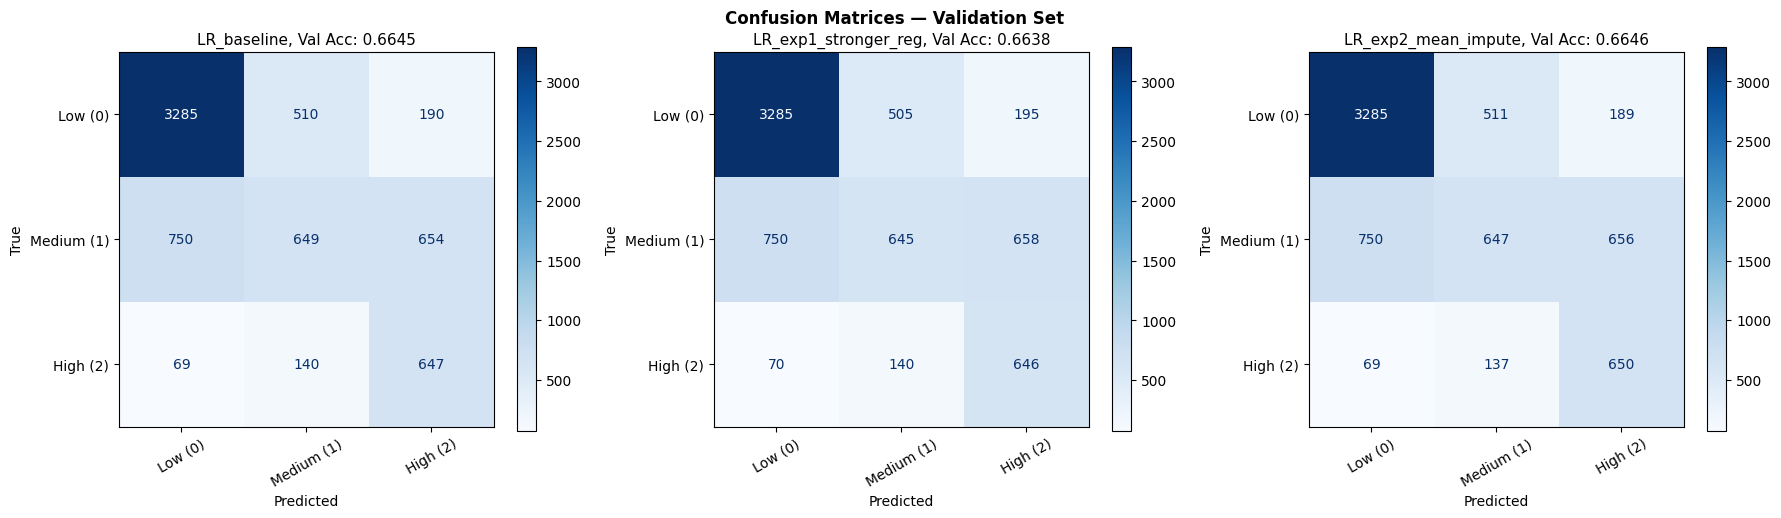

In [56]:
def plot_all_confusion_matrices(experiments, X_val, y_val):
    n = len(experiments)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    if n == 1:
        axes = [axes]

    fig.suptitle('Confusion Matrices — Validation Set', fontsize=12, fontweight='bold')

    for ax, (name, model) in zip(axes, experiments.items()):
        y_val_pred = model.predict(X_val)
        cm         = confusion_matrix(y_val, y_val_pred)
        val_acc    = accuracy_score(y_val, y_val_pred)

        ConfusionMatrixDisplay(
            cm, display_labels=['Low (0)', 'Medium (1)', 'High (2)']
        ).plot(ax=ax, cmap='Blues', values_format='d')

        ax.set_title(f'{name}, Val Acc: {val_acc:.4f}', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices(experiments, X_val, y_val)

## Logistic Regression Experiments: Interpretation

We ran two additional experiments to optimize the logistic regression baseline:

| Experiment | Configuration | Validation Acc | Key Finding |
|------------|---------------|----------------|--------------|
| **Exp 1** | Stronger regularization (C=0.1) | 66.0% | Slight performance drop, no improvement on Class 1 |
| **Exp 2** | Mean imputation | 66.3% | Marginal improvement, same class imbalance pattern |

### Results Summary

All three experiments yielded **similar performance** (66-67% validation accuracy) with identical failure patterns:

- **Class 0 (Low)**: Strong performance (82% accuracy, F1: 0.81)
- **Class 1 (Medium)**: **Critically weak** (32% recall, F1: 0.39) - model misses most moderate events
- **Class 2 (High)**: High recall (76%) but low precision (43%) - over-predicts severe bleaching


Despite tuning efforts (regularization, imputation strategies), logistic regression cannot overcome Non-linear relationships as bleaching severity likely has threshold effects with environmental variables. Feature interactions like temperature, duration, depth are multiplicative not additive which cannot be handled by logistic regression. Lastly linear models struggle with Class imbalance when decision boundaries are dominated by majority classes.

### Conclusion

**Logistic regression is insufficient for this coral bleaching classification problem.** The inability to improve Class 1 recall beyond 32% represents a fundamental limitation of linear models.

**We will now proceed to Random Forest**, which can:
- Capture non-linear patterns automatically
- Detect feature interactions without manual engineering
- Handle class imbalance more effectively through ensemble averaging
- Provide feature importance to identify key environmental drivers

The Random Forest model is expected to significantly improve moderate bleaching detection (Class 1 recall) while maintaining or improving overall accuracy.

#### Test Set Evaluation

,Training accuracy,Validation accuracy,Gap_%,Precision_macro,Recall_macro,F1_macro,"Precision_per_class_[0,1,2]","Recall_per_class_[0,1,2]","F1_per_class_[0,1,2]",Support,Improvement_over_baseline_%_[F1_macro]
LR_baseline (Test Set),0.6596,0.6655,0.9,0.5784,0.6314,0.5808,"[0.7979, 0.5082, 0.4289]","[0.8322, 0.303, 0.7591]","[0.8147, 0.3796, 0.5481]","[3986, 2053, 855]",None


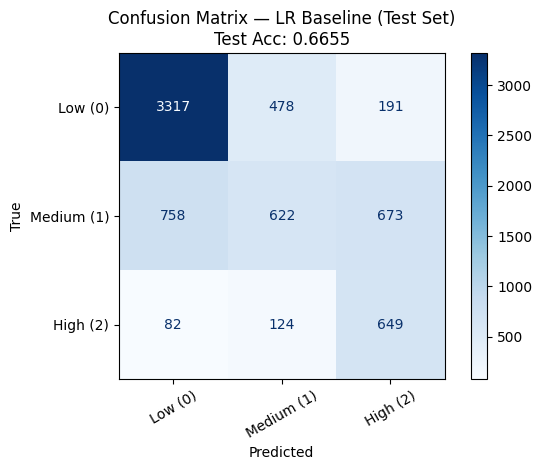

In [54]:
# Evaluated on Baseline model only
# All experiments yielded similar results; baseline selected for final evaluation

baseline_model = experiments["LR_baseline"]

test_results = evaluate_model(
    baseline_model,
    X_train, y_train,
    X_test, y_test    
)

# Display 
test_results_df = pd.DataFrame({"LR_baseline (Test Set)": test_results}).T
display(test_results_df)

# Confusion matrix 
y_test_pred = baseline_model.predict(X_test)
cm_test     = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay(
    cm_test, display_labels=['Low (0)', 'Medium (1)', 'High (2)']
).plot(cmap='Blues', values_format='d')

plt.title(f'Confusion Matrix — LR Baseline (Test Set)\nTest Acc: {test_results["Validation accuracy"]:.4f}')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Readings:
https://reefcloud.ai/

https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/

https://medium.com/@shiwanigupta3005/feature-selection-techniques-for-classification-models-832ebfc6564d

https://pmc.ncbi.nlm.nih.gov/articles/PMC3347893/
<br>Efficient Feature Selection and Multiclass Classification with Integrated Instance and Model Based Learning: ntegrated KNN and constrained logistic regression (KNNLog) for simultaneous multiclass classification and feature selection. This method simultaneously minimizes the intra-class distance and maximizes the interclass distance with fewer estimated parameters. It is very efficient for problems with small sample size and unbalanced classes.